<a href="https://colab.research.google.com/github/monicayar/lab-3/blob/main/lab_3_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Create requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("numpy\n")
    f.write("pandas\n")
    f.write("matplotlib\n")
    f.write("scikit-learn\n")
    f.write("torch\n")

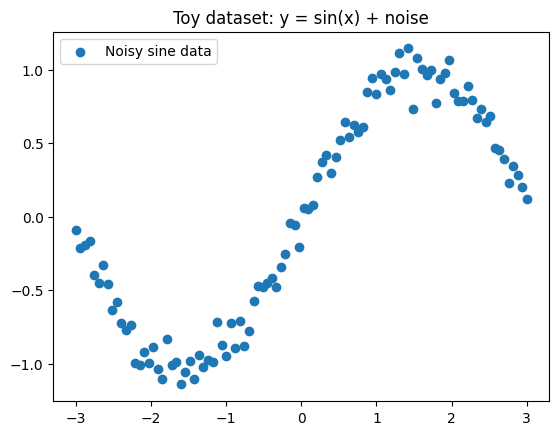

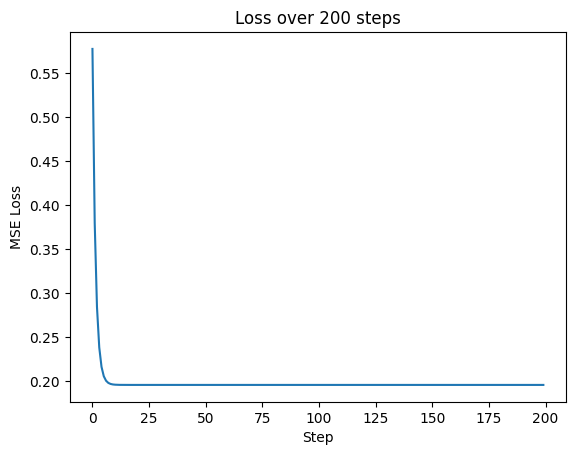

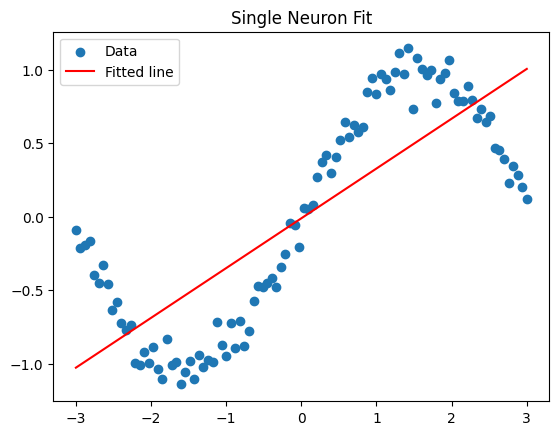

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#  Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.scatter(x, y, label="Noisy sine data")
plt.title("Toy dataset: y = sin(x) + noise")
plt.legend()
plt.show()

#  Initialise parameters
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.05
losses = []

#  Gradient descent loop
for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# Plot loss curve
plt.plot(losses)
plt.title("Loss over 200 steps")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

#  Plot fitted line
plt.scatter(x, y, label="Data")
plt.plot(x, w * x + b, color="red", label="Fitted line")
plt.title("Single Neuron Fit")
plt.legend()
plt.show()


Student Reasoning :The single neuron

Derive dLoss/dw
The loss function is the Mean Squared Error (MSE):

[ L = \frac{1}{n} \sum_{i=1}^{n} (y_{\hat{i}} - y_i)^2 ]

where (y_{\hat{i}} = w \cdot x_i + b).

Taking the derivative with respect to (w):

[ \frac{dL}{dw} = \frac{2}{n} \sum_{i=1}^{n} (y_{\hat{i}} - y_i) \cdot x_i ]

This matches the code implementation:

python dw = np.mean(2 * (y_hat - y) * x)

Underfitting vs Overfitting

The only thing that the neuron can produce is a straight line.

The sine wave is a curved wave that oscillates up and down.

Regardless of the amount of training, one line will never bend to follow the sine.

Therefore, the model is underfitting. It is easier (low capacity) to capture the complexity of the sine wave. Overfitting would imply that the model would learn too much noise, but here the opposite is the issue, i.e., the model is not flexible enough.

Student Reasoning : Hidden layers and activations

A single neuron is only a line.
Adding a hidden layer with nonlinear activation (like tanh) lets the network bend and approximate curves.
Forward pass: (z_1 = xW_1 + b_1), (h = \tanh(z_1)), (y_{\hat} = hW_2 + b_2).
Backward pass uses chain rule: gradients flow from output back through tanh into the input.
Conclusion: depth + activation = flexibility to fit sine wave.
